Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
       open      high       low     close        volume merge_date
0  93347.59  94960.91  92743.63  94383.59   6871.738482 2025-01-01
1  94383.59  97776.99  94177.00  96903.19  10912.473840 2025-01-02
2  96905.48  98969.92  96016.63  98136.51   9021.885382 2025-01-03
3  98139.85  98761.02  97516.65  98209.85   2742.089606 2025-01-04
4  98209.85  98814.00  97250.00  98345.33   2377.921759 2025-01-05
Features shape: (312, 5)
X shape: (100, 150, 5)
Y shape: (100, 63, 5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 256)            │       268,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 63, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 63, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 63, 5)          │         1,285 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 794,885 (3.03 MB)

 Trainable params: 794,885 (3.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
5/5 - 11s - 2s/step - loss: 0.1829 - mae: 0.3484 - val_loss: 0.0418 - val_mae: 0.1658
Epoch 2/50
5/5 - 3s - 516ms/step - loss: 0.0519 - mae: 0.1859 - val_loss: 0.0420 - val_mae: 0.1708
Epoch 3/50
5/5 - 3s - 511ms/step - loss: 0.0359 - mae: 0.1513 - val_loss: 0.0198 - val_mae: 0.1069
Epoch 4/50
5/5 - 3s - 592ms/step - loss: 0.0290 - mae: 0.1352 - val_loss: 0.0179 - val_mae: 0.1017
Epoch 5/50
5/5 - 5s - 969ms/step - loss: 0.0204 - mae: 0.1111 - val_loss: 0.0232 - val_mae: 0.1233
Epoch 6/50
5/5 - 3s - 504ms/step - loss: 0.0209 - mae: 0.1133 - val_loss: 0.0161 - val_mae: 0.0969
Epoch 7/50
5/5 - 3s - 514ms/step - loss: 0.0181 - mae: 0.1042 - val_loss: 0.0154 - val_mae: 0.0955
Epoch 8/50
5/5 - 3s - 506ms/step - loss: 0.0175 - mae: 0.1034 - val_loss: 0.0150 - val_mae: 0.0948
Epoch 9/50
5/5 - 4s - 894ms/step - loss: 0.0162 - mae: 0.0990 - val_loss: 0.0163 - val_mae: 0.1007
Epoch 10/50
5/5 - 3s - 571ms/step - loss: 0.0158 - mae: 0.0984 - val_loss: 0.0143 - val_mae: 0.0931
Epoch 11/50

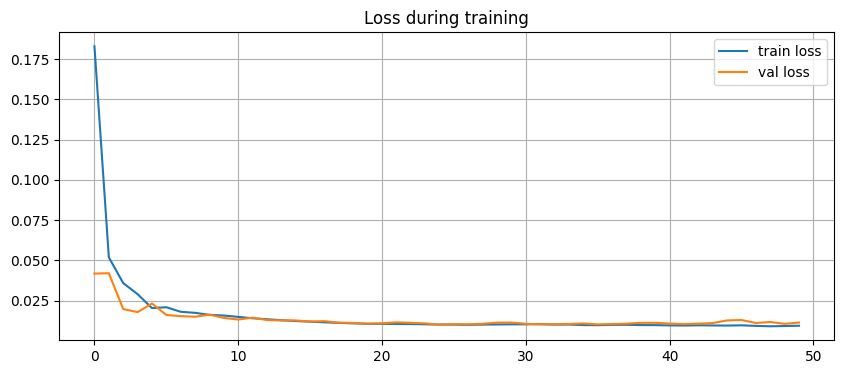

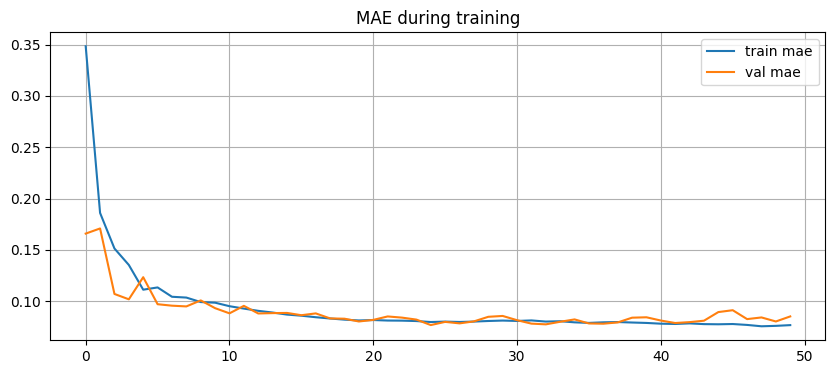

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 824ms/step


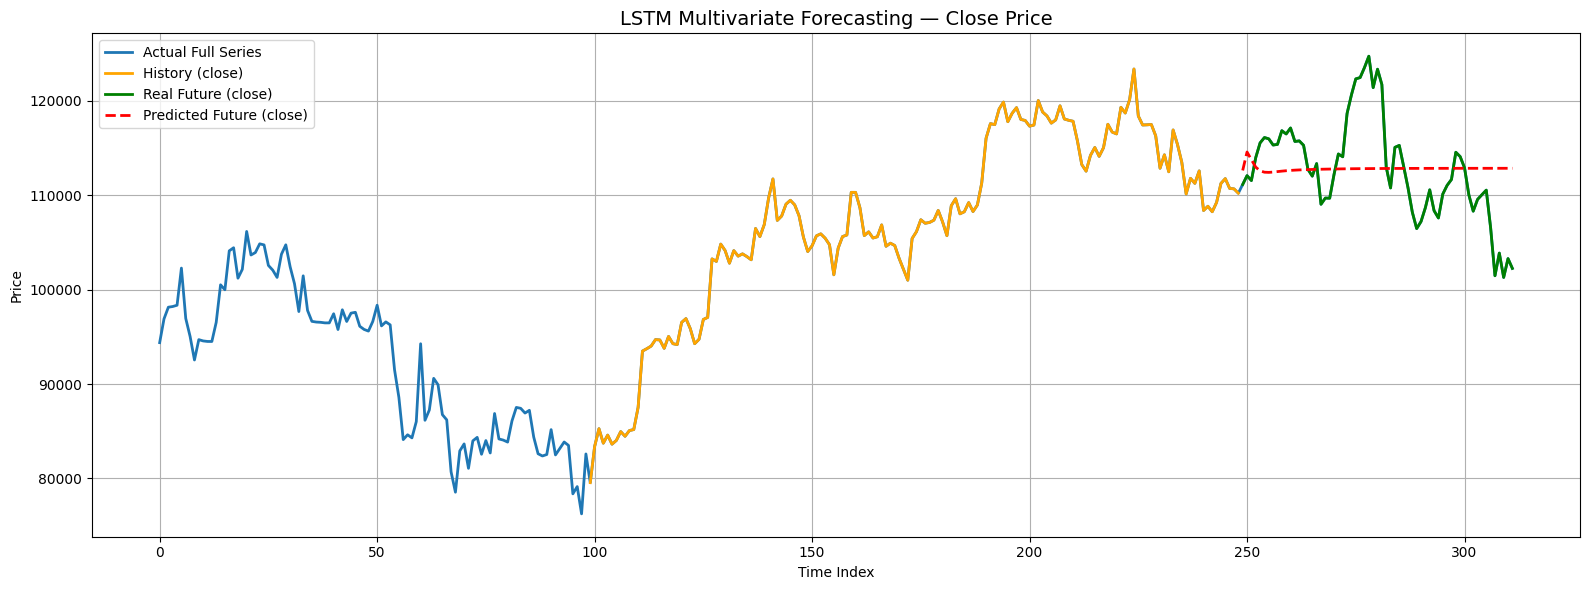

In [4]:
# -*- coding: utf-8 -*-
# ============================================
#   Multivariate LSTM Forecasting (Sliding Window)
#   FEATURES: open, high, low, close, volume
#   HISTORY = 150 , FORECAST = 63
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed

# ============================================================
# 1) خواندن دیتای واقعی از گوگل درایو
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/MyDrive/data/FINAL SELECTED DATA SET/Bitcoin.csv',
    sep=';',
    parse_dates=['merge_date'],
    dayfirst=True
)

print(df.head())

# ============================================================
# 2) انتخاب ویژگی‌ها: open, high, low, close, volume
# ============================================================

features = df[['open', 'high', 'low', 'close', 'volume']].values

# تعداد ویژگی‌ها
n_features = features.shape[1]

print("Features shape:", features.shape)

# ============================================================
# 3) Scaling دیتای چندمتغیره
# ============================================================

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# ============================================================
# 4) Sliding Window
# ============================================================

HISTORY = 150
FORECAST = 63
TOTAL_WIN = HISTORY + FORECAST

X_list = []
Y_list = []

for start in range(len(features_scaled) - TOTAL_WIN + 1):
    end = start + HISTORY
    future_end = end + FORECAST

    X_list.append(features_scaled[start:end])
    Y_list.append(features_scaled[end:future_end, :])  # تمام ویژگی‌ها برای آینده

X = np.array(X_list)
Y = np.array(Y_list)

print("X shape:", X.shape)   # (samples, 150, 5)
print("Y shape:", Y.shape)   # (samples, 63, 5)

# ============================================================
# 5) ساخت مدل LSTM Encoder–Decoder چندمتغیره
# ============================================================

model = Sequential([
    LSTM(256, activation='tanh', input_shape=(HISTORY, n_features)),
    RepeatVector(FORECAST),
    LSTM(256, activation='tanh', return_sequences=True),
    TimeDistributed(Dense(n_features))
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ============================================================
# 6) آموزش مدل چندمتغیره
# ============================================================

history = model.fit(
    X, Y,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=2
)

# ============================================================
# 7) رسم گراف‌های آموزش
# ============================================================

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title("Loss during training")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history['mae'], label='train mae')
plt.plot(history.history['val_mae'], label='val mae')
plt.title("MAE during training")
plt.legend()
plt.grid()
plt.show()

# ============================================================
# 8) پیش‌بینی آینده با استفاده از آخرین 150 پنجره‌ی واقعی
# ============================================================

last_history = features_scaled[-HISTORY:]   # شکل: (150, 5)
input_x = last_history.reshape(1, HISTORY, n_features)

pred_scaled = model.predict(input_x)[0]     # (63, 5)
pred = scaler.inverse_transform(pred_scaled)



# ============================================================
# 10) رسم دقیق — کل تاریخچه + آینده واقعی + پیش‌بینی
# ============================================================

# full series close
full_close = df['close'].values

# last HISTORY برای history واقعی روی نمودار
history_close = full_close[-(HISTORY+FORECAST):-FORECAST]

# آینده واقعی
actual_close = full_close[-FORECAST:]

# آینده پیش‌بینی‌شده
pred_close = pred[:, 3]

# x-axis indices
history_idx = np.arange(len(full_close)-FORECAST-HISTORY, len(full_close)-FORECAST)
future_idx = np.arange(len(full_close)-FORECAST, len(full_close))

plt.figure(figsize=(16,6))

# 1) رسم کل سری واقعی (برای نزدیک شدن به تاریخچه)
plt.plot(np.arange(len(full_close)), full_close, label='Actual Full Series', linewidth=2)

# 2) رسم تاریخچه نزدیک (History)
plt.plot(history_idx, history_close, label='History (close)', linewidth=2, color='orange')

# 3) رسم آینده واقعی
plt.plot(future_idx, actual_close, label='Real Future (close)', linewidth=2, color='green')

# 4) رسم آینده پیش‌بینی‌شده
plt.plot(future_idx, pred_close, '--', label='Predicted Future (close)', linewidth=2, color='red')

plt.title("LSTM Multivariate Forecasting — Close Price", fontsize=14)
plt.xlabel("Time Index")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

